## AIICO STOCK PRICE PREDICTION

In [2]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

aiico=pd.read_csv('../stock_data/AIICO.csv')
aiico=aiico.drop(columns=['high_price','low_price'])
aiico.rename(columns={'trade_date':'date'},inplace=True)
aiico['date']=pd.to_datetime(aiico['date'])
aiico['month']=aiico['date'].dt.month
aiico['quarter']=aiico['date'].dt.quarter
aiico['year']=aiico['date'].dt.year

aiico

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42813,AIICO,2017-01-03,0.60,0.60,356956,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43373,AIICO,2017-01-04,0.61,0.61,180900,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43483,AIICO,2017-01-05,0.62,0.62,838300,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43593,AIICO,2017-01-06,0.62,0.62,81591,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43683,AIICO,2017-01-09,0.60,0.60,7669839,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298023,AIICO,2026-07-13,3.96,3.96,6133839,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298461,AIICO,2026-07-14,3.96,3.96,3349343,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298899,AIICO,2026-07-15,3.96,3.96,3986502,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299337,AIICO,2026-07-16,4.04,4.04,6691535,2026-07-16T15:10:03.113936+00:00,7,3,2026


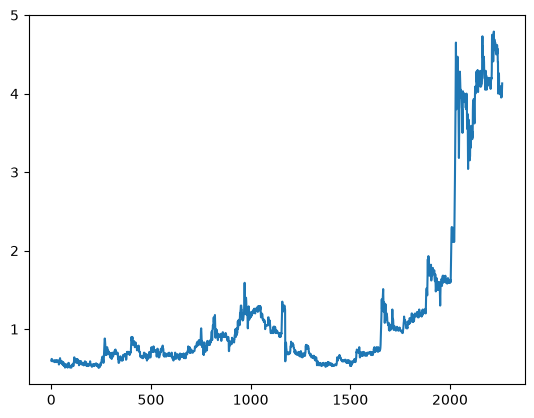

In [3]:
import matplotlib.pyplot as plt

plt.plot(aiico['close_price'])
plt.show()

In [4]:
aiico_end_month_df = (
    aiico
    .sort_values("date")
    .groupby(aiico["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

aiico_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45383,AIICO,2017-01-31,0.59,0.59,12810930,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47205,AIICO,2017-02-28,0.57,0.57,95700,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49321,AIICO,2017-03-31,0.53,0.53,5236900,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51149,AIICO,2017-04-28,0.53,0.53,687622,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53071,AIICO,2017-05-31,0.52,0.52,1915346,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35260,AIICO,2026-03-31,4.10,4.10,20685415,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281087,AIICO,2026-04-30,4.31,4.31,28504829,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284153,AIICO,2026-05-29,4.55,4.55,10434470,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294081,AIICO,2026-06-30,4.01,4.01,5801686,2026-06-30T15:10:03.08168+00:00,6,2,2026


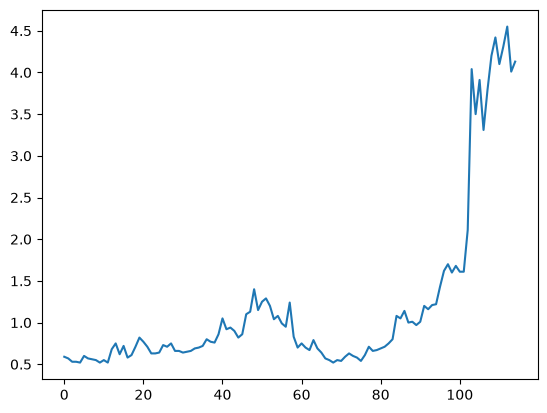

In [5]:
plt.plot(aiico_end_month_df['close_price'])
plt.show()

In [6]:
aiico_end_month_df['returns']=aiico_end_month_df['close_price'].pct_change()*100
aiico_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45383,AIICO,2017-01-31,0.59,0.59,12810930,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47205,AIICO,2017-02-28,0.57,0.57,95700,2026-04-08T02:44:45.006295+00:00,2,1,2017,-3.389831
2,49321,AIICO,2017-03-31,0.53,0.53,5236900,2026-04-08T02:45:42.281198+00:00,3,1,2017,-7.017544
3,51149,AIICO,2017-04-28,0.53,0.53,687622,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53071,AIICO,2017-05-31,0.52,0.52,1915346,2026-04-08T02:52:57.421655+00:00,5,2,2017,-1.886792
...,...,...,...,...,...,...,...,...,...,...,...
110,35260,AIICO,2026-03-31,4.10,4.10,20685415,2026-03-31T15:00:02.085058+00:00,3,1,2026,-7.239819
111,281087,AIICO,2026-04-30,4.31,4.31,28504829,2026-04-30T15:00:02.170664+00:00,4,2,2026,5.121951
112,284153,AIICO,2026-05-29,4.55,4.55,10434470,2026-05-29T15:00:02.455558+00:00,5,2,2026,5.568445
113,294081,AIICO,2026-06-30,4.01,4.01,5801686,2026-06-30T15:10:03.08168+00:00,6,2,2026,-11.868132


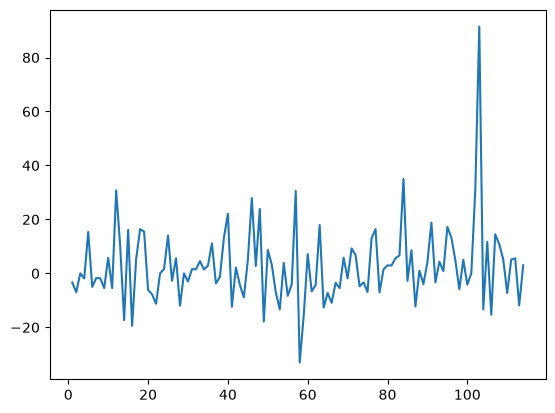

In [7]:
plt.plot(aiico_end_month_df['returns'])
plt.show()

In [8]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(aiico_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-11.031871480193765), np.float64(5.641643237618571e-20), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(822.6364465783452))
stationary


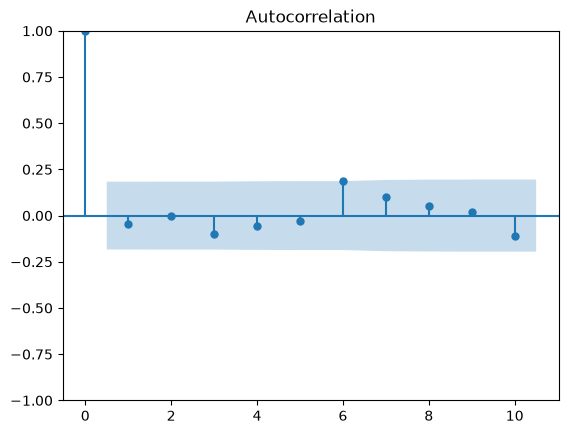

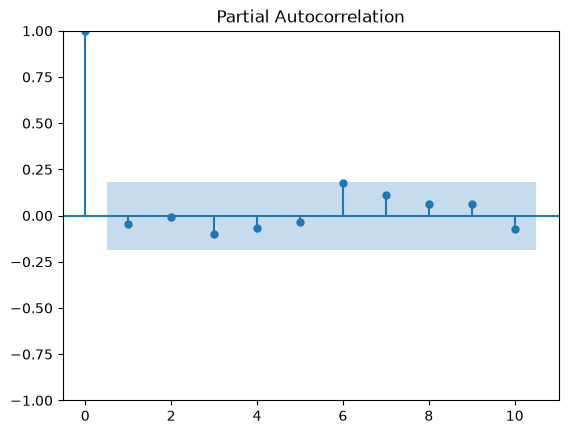

In [9]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(aiico_end_month_df['returns'].dropna(), lags=10)
plot_pacf(aiico_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [10]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [11]:
train=aiico_end_month_df['close_price'][:-10]
test=aiico_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -148.51549225163612]
[0, 0, 0, 0, 0, 1, -87.7958166678069]
[0, 0, 0, 0, 0, 2, -76.00919384974024]
[0, 0, 0, 0, 1, 0, -55.340945918120724]
[0, 0, 0, 0, 1, 1, -47.93307112048672]
[0, 0, 0, 0, 1, 2, -46.95880791371075]
[0, 0, 0, 0, 2, 0, -31.486280339280086]
[0, 0, 0, 0, 2, 1, -33.55943970661273]
[0, 0, 0, 0, 2, 2, -38.01412154629473]
[0, 0, 0, 1, 0, 0, -60.7407840377747]
[0, 0, 0, 1, 0, 1, -54.151288995371374]
[0, 0, 0, 1, 0, 2, -55.259170903195724]
[0, 0, 0, 1, 1, 0, -47.151357280176136]
[0, 0, 0, 1, 1, 1, -47.65010862005378]
[0, 0, 0, 1, 1, 2, -49.89331672389866]
[0, 0, 0, 1, 2, 0, -32.43225122619065]
[0, 0, 0, 1, 2, 1, -36.412336764692874]
[0, 0, 0, 1, 2, 2, -37.46073470041898]
[0, 0, 0, 2, 0, 0, -54.80231321467326]
[0, 0, 0, 2, 0, 1, -54.45149529673948]
[0, 0, 0, 2, 0, 2, -53.43405088278013]
[0, 0, 0, 2, 1, 0, -50.72961425448272]
[0, 0, 0, 2, 1, 1, -51.2048961775401]
[0, 0, 0, 2, 1, 2, -51.91837386059004]
[0, 0, 0, 2, 2, 0, -35.59044478549222]
[0, 0, 0, 2, 2, 1, -3

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-148.515492
27,0,0,1,0,0,0,-144.035709
54,0,0,2,0,0,0,-141.926844
162,0,2,0,0,0,0,-139.083884
661,2,2,0,1,1,1,-129.482119
...,...,...,...,...,...,...,...
623,2,1,2,0,0,2,0.316887
631,2,1,2,1,0,1,0.328908
632,2,1,2,1,0,2,0.333627
639,2,1,2,2,0,0,0.337778


[2	1	2	1	0	0] is the best. We will work with it.

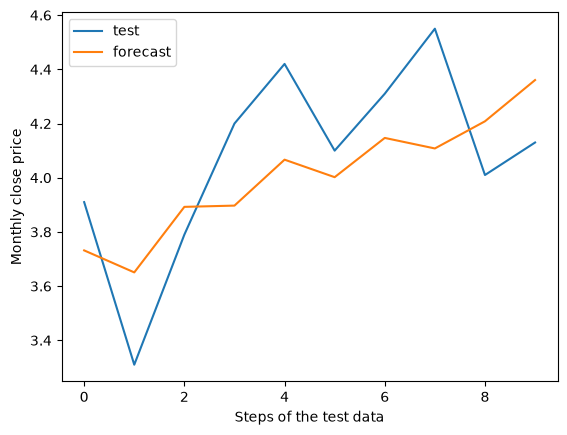

r2_score:  0.3743498710320101
rmse:  0.2643591213781991


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=aiico_end_month_df['close_price'][:-10]
y_test=aiico_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,2), 
seasonal_order=(1,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

In [14]:
aiico_end_month_df['close_price'].describe()

count    115.000000
mean       1.184957
std        1.026091
min        0.520000
25%        0.640000
50%        0.760000
75%        1.155000
max        4.550000
Name: close_price, dtype: float64

Did not really capture the variations very well. But we can work with it.